Analyse par réseau de neurone

In [ ]:
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn import decomposition
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import random
import datetime as dt


from datasets import load_dataset
from transformers import AutoTokenizer


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from torch.utils.data import Dataset

/Users/baptistetrt/Desktop/Etudes/Ponts/S2/MIEDE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.__version__)
print(torch.cuda.get_device_name(0))

True
12.6
2.10.0+cu126
NVIDIA GeForce RTX 3050 Laptop GPU


Output & Input

In [ ]:
data_file=r"Data\RES2-6-9.csv"
conso_file = open(data_file)
data = conso_file.readlines()[1:]
DATA=[]
DATES=[]
sdates=set()
ID = []
sid = set()
for i in data:
    line = i.split(';')
    line[0]  = int(line[0])
    time = line[1]
    line[1] = dt.date(int(time[:4]), int(time[5:7]), int(time[8:10]))
    DATA.append(line)
    line[2]=float(line[2][:-1])
    if line[1] not in sdates:
        sdates.add(line[1])
        DATES.append(line[1])
    if line[0] not in sid:
        sid.add(line[0])
        ID.append(line[0])
test = DATA[0]
print(test)


[476866365062, datetime.date(2023, 11, 1), 1328.1]


In [ ]:
Conso={i: 0 for i in DATES}
Conso_indiv = {i: Conso.copy() for i in ID}
for line in DATA:
    Conso_indiv[line[0]][line[1]] += line[2]

DATA.clear()

In [ ]:
X = []
Y = []
date_lim = DATES[int(4*len(DATES)/5)]
print(date_lim)
for id in ID:
    conso_begin = []
    conso_end = []
    for date in DATES:
        if date > date_lim:
            conso_end.append(Conso_indiv[id][date])
        else:
            conso_begin.append(Conso_indiv[id][date])
    X.append(conso_begin)
    Y.append(conso_end)  
Edata = len(X[0])
Odata = len(Y[0]) 
X=np.array(X)
Y=np.array(Y) 
"""print("Entry data seize:", len(X[0]))
print("Output data seize:", len(Y[0]))"""

2024-08-18


'print("Entry data seize:", len(X[0]))\nprint("Output data seize:", len(Y[0]))'

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.33)
print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])   

Train size: 350
Test size : 100


***First polynomial model - SKlearn***

In [ ]:
def train_pred(N, X_training, y_training):
    poly = PolynomialFeatures(N)
    X_poly = poly.fit_transform(X_training)

    model = LinearRegression()
    model.fit(X_poly, y_training)

    y_pred = model.predict(X_poly)
    return y_pred

def Poly_network(N, X, y):
    y_pred = train_pred(N, X, y)
    #RMSE = 

    for num in range(3):
        train = np.concatenate((X_test[num], y_test[num]), axis=0)
        pred=np.concatenate(([0 for i in range(len(X_test[num]))], y_pred[num]), axis=0)

        plt.plot(train , 'b')
        plt.plot(pred , 'r')

        plt.show()

N = 2
#Poly_network(N)


Problem is sklearn is a CPU only library, I can't make it run with N>2...

***PCA - SKlearn***

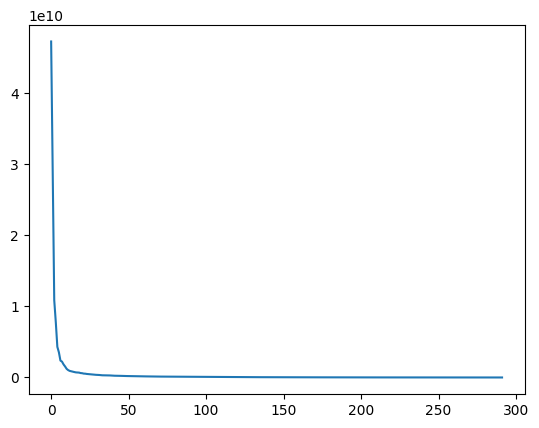

In [ ]:
pca = decomposition.PCA()
pca.fit(X_train)
plt.plot(pca.explained_variance_)
plt.title("Variance en fonction du noombre de PCA")
mean=pca.mean_

In [ ]:
def prop_var(k):
    return sum([pca.explained_variance_[i] for i in range(k)])/sum(pca.explained_variance_)

def nb_comp(q):
    k=0
    while prop_var(k)<q:
        k+=1
    return k

N_compo=nb_comp(0.90)
print(f"Nombre de composantes pour avoir un taux de 90%: {N_compo}")

Nombre de composantes pour avoir un taux de 90%: 35


Reduction de dimension

(35,)


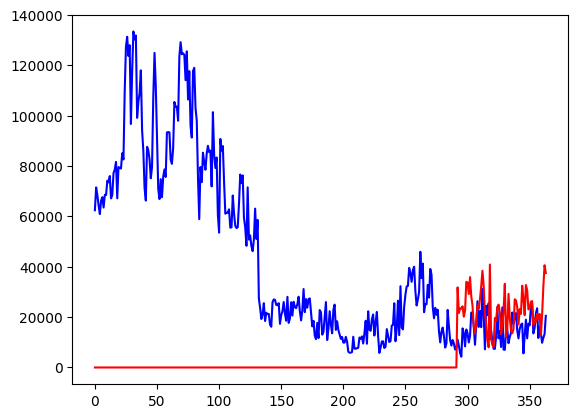

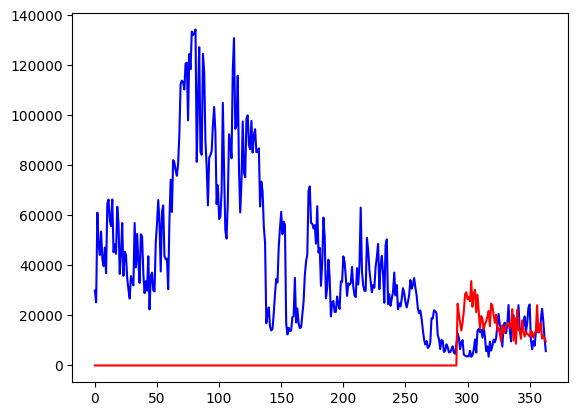

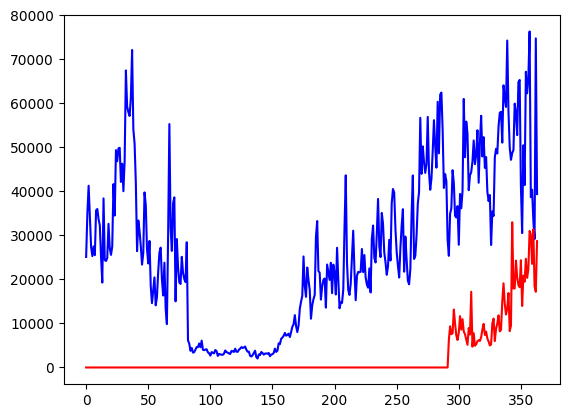

In [ ]:
pca_red = decomposition.PCA(n_components=N_compo) # Number of components for dimension reduction
pca_red.fit(X_train)

def reduce_dim(x):
  tf = pca_red.transform(x.reshape(1,-1)) # Coordinates in the basis of the first k principal axes
  return tf[0]

X_train_reduct = np.array([reduce_dim(i) for i in X_train])#.reshape(-1, 1)
print(X_train_reduct[0].shape)
X_test_reduct = np.array([reduce_dim(i) for i in X_test])#.reshape(-1, 1)
X_val_reduct = np.array([reduce_dim(i) for i in X_val])#.reshape(-1, 1)

N=3
Poly_network(N, X_train_reduct, y_train)

***Second model - Pytorch***

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

In [ ]:
# Create DataLoaders
batch_size = 8

Train = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size, shuffle=True)
Val   = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size, shuffle=False)
Test  = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size, shuffle=False)

In [ ]:
def RMSE(model):
        RMSE = 0
        for num in range(len(X_test)):
                y_true = y_test[num]
                X_test_tensor = torch.tensor(X_test[num], dtype=torch.float32).unsqueeze(0).to(device)
                y_pred = model(X_test_tensor).cpu().detach().numpy()[0]
                RMSE += sum([(y_true[i]-y_pred[i])**2 for i in range(len(y_true))])
        return np.sqrt(RMSE)

In [ ]:
class MLPPredict(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # A simple MLP with 2 hidden layers:
        # input_dim -> hidden_dim -> hidden_dim -> num_classes
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim))
    
    def forward(self, x):
        return self.network(x)



def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch=1, num_epochs=1):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs} [Train]", leave=False)

    for IDs, labels in progress_bar:

        IDs = IDs.to(device)
        labels = labels.to(device)
        labels = labels.argmax(dim=1)  # Convert one-hot → class index
        optimizer.zero_grad()
        outputs = model(IDs)

        #print(outputs.shape)   # doit être [batch_size, 72]
        #print(labels.shape)

        """print("Criterion:", type(criterion))
        print("Outputs shape:", outputs.shape)
        print("Labels shape:", labels.shape)"""

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        total_loss += loss.item() * IDs.size(0)

        _, predicted = outputs.max(dim=1)

        correct += predicted.eq(labels).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = 100.0 * correct / total

    return avg_loss, avg_acc


In [ ]:
def evaluate(model, dataloader, criterion, device, desc="Val"):

    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc=f"[{desc}]", leave=False)

    with torch.no_grad():
        for IDs, labels in progress_bar:

            IDs = IDs.to(device)
            labels = labels.to(device)
            labels = labels.argmax(dim=1)
            outputs = model(IDs)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * IDs.size(0)
            _, predicted = outputs.max(dim=1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = 100.0 * correct / total

    return avg_loss, avg_acc

In [ ]:
def train_model(model, train_loader, val_loader, test_loader, criterion, optimizer, device, num_epochs=5):

  #print(summary(model, input_size=(64, 292)))

  best_val_acc = 0.0
  best_test_acc = 0.0  # Will store the highest test acc reached

  for epoch in range(1, num_epochs+1):
      # Train one epoch
      train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
      #print(RMSE(model))

      # Evaluate on validation set
      val_loss, val_acc = evaluate(model, val_loader, criterion, device)

      # Print color-coded lines for train and val
      """print(f"\033[94m[Epoch {epoch} / {num_epochs}]\033[0m "
            f"Train Loss: {train_loss:.2f}, Train Acc: {train_acc:.1f}% | "
            f"Val Loss: {val_loss:.2f}, Val Acc: {val_acc:.1f}%")"""

      # Check if best on val -> Evaluate on test
      if val_acc > best_val_acc:
        best_val_acc = val_acc

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        # Update best_test_acc if needed
        if test_acc > best_test_acc:
            best_test_acc = test_acc

            print(f"\033[92m  -> New best val acc! "
                  f"Test Loss: {test_loss:.2f}, Test Acc: {test_acc:.1f}%\033[0m")
  return model, best_test_acc

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
def plot_test(num, y_pred):    
        train = np.concatenate((X_test[num], y_test[num]), axis=0)
        y_max = max(X_test[num])
        y_min = min(X_test[num])
        y_pred_denorm = [y_pred[i] * (y_max - y_min) + y_min for i in range(len(y_pred))]
        pred = np.concatenate(([0 for i in range(len(X_test[num]))], y_pred_denorm), axis=0)
        plt.plot(train , 'b')
        plt.plot(pred , 'r')
        plt.show()

def plot_train(num):
        pass



In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = MLPPredict(input_dim= 292, hidden_dim= 100, output_dim= 72).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 5

train_model(model, Train, Val, Test, criterion, optimizer, device, num_epochs)

model.eval()
print(RMSE(model))

  -> New best val acc! Test Loss: 588.29, Test Acc: 1.0%


  -> New best val acc! Test Loss: 9.29, Test Acc: 11.0%


2226792.325107552


In [ ]:
def RMSE_variation_hidden_layer():
    RMSE_liste=[]
    for hid_dim in range(1, 500, 20):
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        model = MLPPredict(input_dim= 292, hidden_dim= hid_dim, output_dim= 72).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        num_epochs = 5

        train_model(model, Train, Val, Test, criterion, optimizer, device, num_epochs)

        model.eval()
        RMSE_liste.append(RMSE(model))
    plt.plot([i for i in range(1, 500, 20)], RMSE_liste)
#RMSE_variation_hidden_layer()

def RMSE_variation_epochs():
    RMSE_liste=[]
    for num_epochs in range(1, 15, 1):
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        model = MLPPredict(input_dim= 292, hidden_dim= 100, output_dim= 72).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        train_model(model, Train, Val, Test, criterion, optimizer, device, num_epochs)

        model.eval()
        RMSE_liste.append(RMSE(model))
    plt.plot([num_epochs for num_epochs in range(1, 15, 1)], RMSE_liste)
#RMSE_variation_epochs()

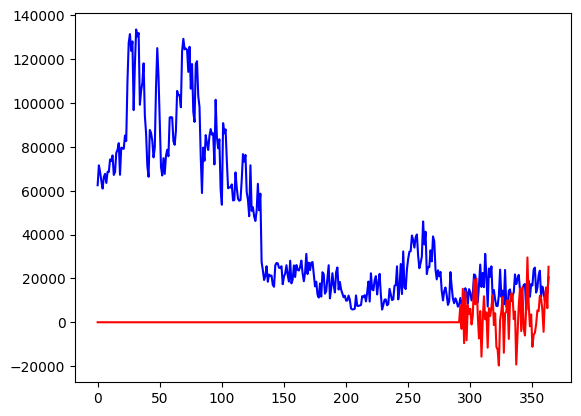

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

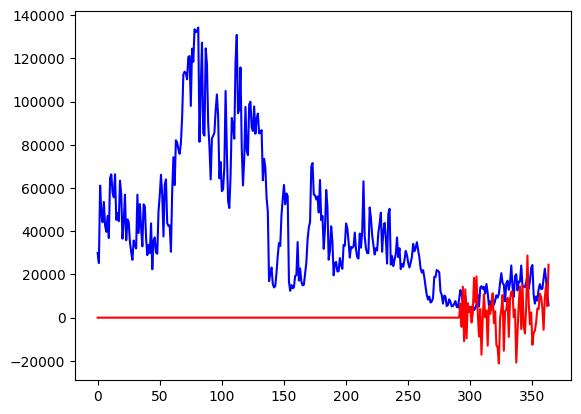

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

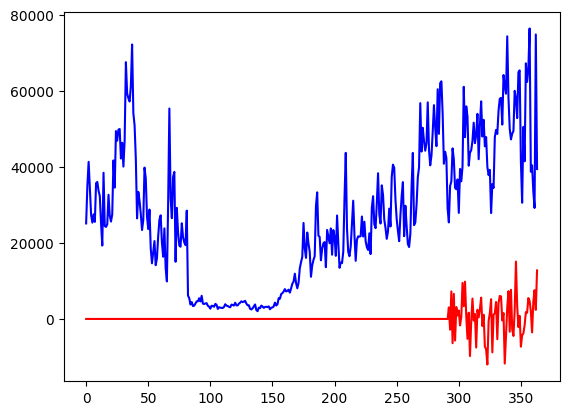

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

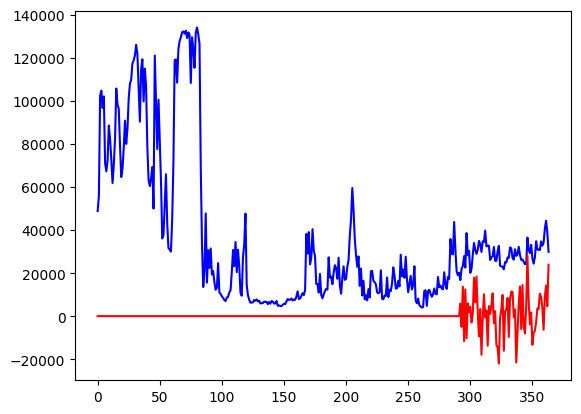

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

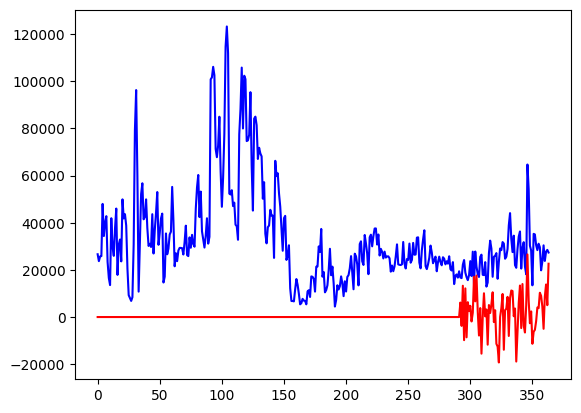

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

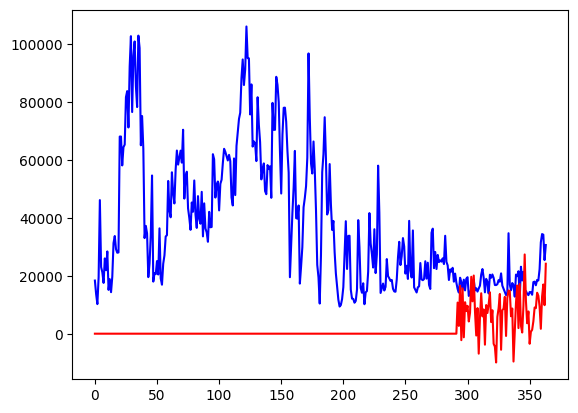

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

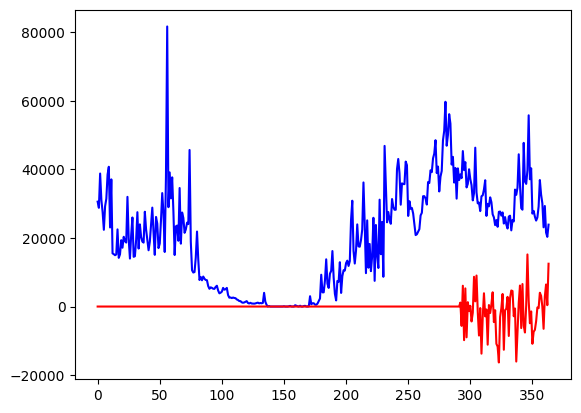

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

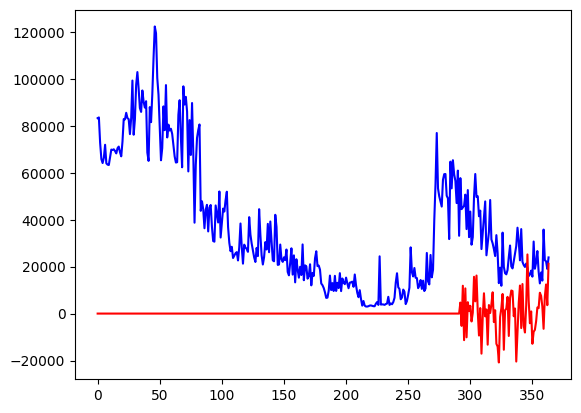

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

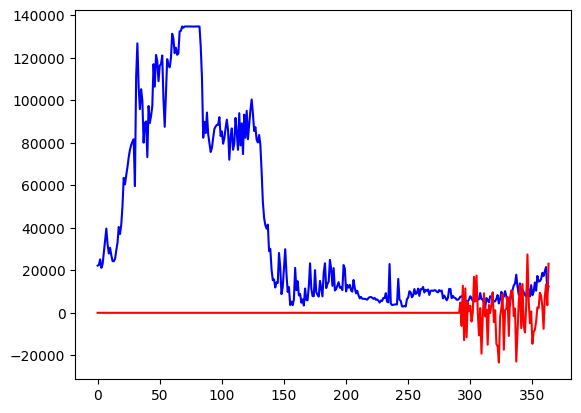

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

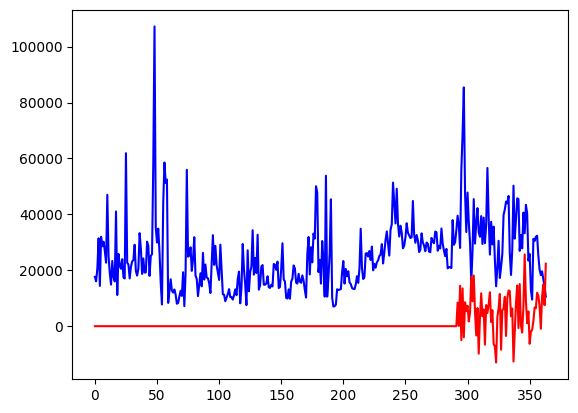

[ 1.41599383e-02 -6.91023618e-02  7.42606595e-02 -1.20036468e-01
  6.48160651e-02 -1.09882675e-01  1.55087672e-02 -1.64342523e-02
  2.56283768e-03 -5.32746874e-02 -2.21143793e-02  1.06294662e-01
  1.86247602e-02  1.10730194e-01 -1.79842319e-02 -1.03479140e-01
 -5.52338408e-03 -1.68209106e-01 -3.85441892e-02  4.73939553e-02
 -3.50557566e-02 -1.03920493e-02 -1.36180490e-01  5.34447003e-03
 -2.30572093e-02  7.96923880e-03  5.08440062e-02 -5.55395596e-02
 -1.32810203e-02 -1.32903352e-01 -1.43058106e-01 -1.99727833e-01
 -3.71607579e-02 -6.24488667e-03  4.49170135e-02 -1.54293627e-01
 -1.30114108e-02 -7.55681144e-03  3.45548429e-02 -1.05038524e-01
  3.00939344e-02  5.73696308e-02  5.53399660e-02 -3.46067399e-02
 -7.05304230e-03 -1.96385473e-01 -9.24898535e-02  1.31635629e-02
  7.50490203e-02 -7.69074708e-02  8.03647637e-02 -6.81509003e-02
 -9.27014723e-02  3.80496099e-03  1.85982183e-01  2.05593426e-02
 -5.96738942e-02 -1.74756832e-02 -1.32970080e-01 -8.99374411e-02
 -8.32191035e-02 -5.24753

In [ ]:
N_plots = 10
for num in range(N_plots):
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test[num], dtype=torch.float32).unsqueeze(0).to(device)
        y_pred = model(X_test_tensor).cpu().numpy()[0]  # récupère sur CPU pour plotting
        X_train_tensor = torch.tensor(X_test[num], dtype=torch.float32).unsqueeze(0).to(device)
        y_pred_train = model(X_train_tensor).cpu().numpy()[0]
    plot_test(num, y_pred)
    print(y_pred)